## Environment code


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from enum import IntEnum
from typing import Any, Protocol

import gymnasium as gym
import numpy as np
from gymnasium import spaces

from utils.config import RuleSet
from utils.scoring import legal_keeps, score_counts  


class Decision(IntEnum):
    ROLL = 0
    BANK = 1


class OpponentPolicy(Protocol):
    def play_turn(
        self, rules: RuleSet, rng: np.random.Generator,
        own_score: int, best_rival_score: int, on_board: bool,
    ) -> int:
        """Play one full turn; return points actually banked (0 on farkle)."""

In [2]:
@dataclass(frozen=True)
class ThresholdOpponent:
    """Baseline opponent: take the best scoring keep and bank at a threshold."""

    bank_at: int = 500

    def play_turn(
        self, rules: RuleSet, rng: np.random.Generator,
        own_score: int, best_rival_score: int, on_board: bool,
    ) -> int:
        dice_left, turn_score = rules.num_dice, 0
        while True:
            counts = np.bincount(rng.integers(1, 7, size=dice_left) - 1,
                                 minlength=6)
            keeps = legal_keeps(counts, rules)
            if not keeps:
                return 0
            dice_used, (score, _) = max(
                keeps.items(), key=lambda item: (item[1][0], item[0])
            )
            turn_score += score
            dice_left -= dice_used
            can_bank = on_board or turn_score >= rules.min_first_bank
            if can_bank and (
                turn_score >= self.bank_at
                or own_score + turn_score >= rules.target_score
                or (dice_left == 0 and not rules.hot_dice)
            ):
                return turn_score
            if dice_left == 0:
                if not rules.hot_dice:
                    return 0  # Cannot roll or meet the entry threshold.
                dice_left = rules.num_dice


In [3]:
class FarkleEnv(gym.Env):
    """Farkle from one seat. Opponent turns are simulated inside `step`.

    Action space is flat: 2 * num_dice actions, decoded as
    (dice_kept, Decision). `dice_kept` selects the *highest-scoring* keep
    that uses exactly that many dice -- lower-scoring keeps of the same
    size are provably dominated, since the turn's future depends only on
    (dice_left, turn_score).
    """

    metadata = {"render_modes": ["human", "ansi"]}

    def __init__(
        self,
        rules: RuleSet | str = "configs/rules/standard_10k.yaml",
        opponent: OpponentPolicy | None = None,
        reward_mode: str = "points",       # "points" | "win" | "both"
        max_turns: int = 50,
        render_mode: str | None = None,
    ):
        super().__init__()
        self.rules = rules if isinstance(rules, RuleSet) else RuleSet.from_yaml(rules)
        self.rules.validate()
        self.opponent = opponent if opponent is not None else ThresholdOpponent()
        self.reward_mode = reward_mode
        self.max_turns = max_turns
        self.render_mode = render_mode

        n = self.rules.num_dice
        self.action_space = spaces.Discrete(2 * n)
        self.observation_space = spaces.Dict({
            "roll": spaces.MultiDiscrete([n + 1] * 6),
            "dice_left": spaces.Discrete(n + 1),
            "turn_score": spaces.Box(0.0, np.inf, shape=(1,), dtype=np.float32),
            "my_score": spaces.Box(0.0, np.inf, shape=(1,), dtype=np.float32),
            "opp_score": spaces.Box(0.0, np.inf, shape=(1,), dtype=np.float32),
            "on_board": spaces.Discrete(2),
            "opp_on_board": spaces.Discrete(2),
            "final_round": spaces.Discrete(2),
            "finisher": spaces.Discrete(3),  # 0=none, 1=me, 2=opponent
            "turns_remaining": spaces.Discrete(max_turns + 1),
        })
        self._terminated = False
        self._truncated = False
        self._counts = np.zeros(6, dtype=np.int64)
        self._keeps = {}

    def _decode(self, action: int) -> tuple[int, Decision]:
        return action // 2 + 1, Decision(action % 2)

    def _encode(self, dice_kept: int, decision: Decision) -> int:
        return (dice_kept - 1) * 2 + int(decision)

    def action_mask(self) -> np.ndarray:
        mask = np.zeros(self.action_space.n, dtype=bool)
        if self._terminated or self._truncated:
            return mask
        if not self._keeps:
            mask[0] = True  # A farkle on the opening roll: forced pass.
            return mask
        for dice_used, (score, _) in self._keeps.items():
            remaining = self._dice_left - dice_used
            if remaining > 0 or self.rules.hot_dice:
                mask[self._encode(dice_used, Decision.ROLL)] = True
            if (self._bank_allowed(self._turn_score + score)
                    or (remaining == 0 and not self.rules.hot_dice)):
                # On non-hot dice, below-threshold banking can be a forced
                # zero-point turn when no more dice remain.
                mask[self._encode(dice_used, Decision.BANK)] = True
        return mask

    def _bank_allowed(self, prospective_total: int) -> bool:
        """Banking below the first-bank threshold scores nothing and ends the
        turn -- strictly dominated by rolling, since the turn score at risk is
        already worth zero. Mask it out."""
        if self._on_board:
            return True
        return prospective_total >= self.rules.min_first_bank


    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self._my_score = 0
        self._opp_score = 0
        self._on_board = False
        self._opp_on_board = False
        self._turn_count = 0
        self._final_round = False
        self._finisher: str | None = None
        self._terminated = False
        self._truncated = False
        self._begin_turn()
        return self._obs(), self._info()

    def step(self, action: int):
        if self._terminated or self._truncated:
            raise RuntimeError("episode finished; call reset()")
        if not self.action_space.contains(action):
            raise ValueError(f"action outside action space: {action}")
        action = int(action)
        if not self.action_mask()[action]:
            raise ValueError(f"illegal action {action}")

        banked = 0
        if not self._keeps:
            # The opening roll farkled. Action 0 consumes this turn.
            self._end_turn()
        else:
            dice_kept, decision = self._decode(action)
            score, _ = self._keeps[dice_kept]
            self._turn_score += score
            self._dice_left -= dice_kept
            if decision is Decision.BANK:
                banked = self._bank()
                self._end_turn()
            else:
                if self._dice_left == 0:  # Hot dice; ROLL is otherwise masked.
                    self._dice_left = self.rules.num_dice
                self._roll()
                if not self._keeps:
                    self._turn_score = 0
                    self._end_turn()

        reward = self._reward(banked, self._terminated)
        if self.render_mode == "human":
            self.render()
        return self._obs(), reward, self._terminated, self._truncated, self._info()



    def _roll(self) -> None:
        """Roll self._dice_left dice into self._counts; recompute self._keeps."""
        rolled = np.random.choice(range(1,7),self._dice_left)
        self._counts = np.bincount(rolled - 1, minlength=6)
        self._keeps = legal_keeps(self._counts, self.rules)
        

    def _begin_turn(self) -> None:
        """Reset turn score, dice_left = num_dice, roll. NB: the opening roll
        can itself be a farkle -- handle a zero-length turn."""
        self._turn_score = 0
        self._dice_left = self.rules.num_dice
        self._roll()


    def _bank(self) -> int:
        if not self._bank_allowed(self._turn_score):
            return 0
        banked = self._turn_score
        self._my_score += banked
        self._on_board = True
        if self._finisher is None and self._my_score >= self.rules.target_score:
            self._finisher = "me"
            self._final_round = bool(self.rules.final_round)
        return banked

    def _end_turn(self) -> None:
        """Resolve the opponent and the two possible final-round orders."""
        self._turn_count += 1
        # If the opponent crossed on its preceding turn, this was my reply.
        if self._finisher == "opp":
            self._terminated = True
            return
        if self._finisher == "me" and not self.rules.final_round:
            self._terminated = True
            return

        gained = self.opponent.play_turn(
            self.rules, self.np_random, self._opp_score,
            self._my_score, self._opp_on_board,
        )
        if not isinstance(gained, (int, np.integer)) or gained < 0:
            raise ValueError("opponent must return nonnegative integer banked points")
        if gained:
            if not self._opp_on_board and gained < self.rules.min_first_bank:
                raise ValueError("opponent banked below its entry threshold")
            self._opp_score += int(gained)
            self._opp_on_board = True
            if self._finisher is None and self._opp_score >= self.rules.target_score:
                self._finisher = "opp"
                self._final_round = bool(self.rules.final_round)

        # If I reached the target first, the opponent just took its last turn.
        if self._finisher == "me" or (
            self._finisher == "opp" and not self.rules.final_round
        ):
            self._terminated = True
        elif self._turn_count >= self.max_turns:
            self._truncated = True
        else:
            self._begin_turn()

    def _reward(self, banked: int, terminated: bool) -> float:
        point_reward = banked / self.rules.target_score
        outcome_reward = (float(self._my_score > self._opp_score)
                          - float(self._my_score < self._opp_score)) if terminated else 0.0
        if self.reward_mode == "points":
            return point_reward
        if self.reward_mode == "win":
            return outcome_reward
        return point_reward + outcome_reward

    def _obs(self) -> dict[str, Any]:
        target = float(self.rules.target_score)
        return {
            "roll": self._counts.copy(),
            "dice_left": self._dice_left,
            "turn_score": np.array([self._turn_score / target], dtype=np.float32),
            "my_score": np.array([self._my_score / target], dtype=np.float32),
            "opp_score": np.array([self._opp_score / target], dtype=np.float32),
            "on_board": int(self._on_board),
            "opp_on_board": int(self._opp_on_board),
            "final_round": int(self._final_round),
            "finisher": {None: 0, "me": 1, "opp": 2}[self._finisher],
            "turns_remaining": max(0, self.max_turns - self._turn_count),
        }

    def _info(self) -> dict[str, Any]:
        return {
            "action_mask": self.action_mask(),
            "turn_score": self._turn_score,
            "my_score": self._my_score,
            "opp_score": self._opp_score,
            "turn_count": self._turn_count,
            "winner": ("me" if self._my_score > self._opp_score else
                       "opp" if self._opp_score > self._my_score else "tie")
                       if self._terminated else None,
            "rules_fingerprint": self.rules.fingerprint(),
        }

    def render(self):
        if self.render_mode is None:
            return None
        description = (f"roll={self._counts.tolist()} left={self._dice_left} "
                       f"turn={self._turn_score} scores={self._my_score}:"
                       f"{self._opp_score} finisher={self._finisher}")
        if self.render_mode == "human":
            print(description)
            return None
        return description

In [11]:
# Minimal self-contained game: no YAML file required.
demo_rules = RuleSet(
    name="smoke", num_dice=6, target_score=1000, min_first_bank=500,
    final_round=True, hot_dice=True,
    singles={1: 100, 5: 50},
    triple={1: 1000, 2: 200, 3: 300, 4: 400, 5: 500, 6: 600},
    multiplier={3: 1, 4: 2, 5: 4, 6: 8},
)
env = FarkleEnv(demo_rules, max_turns=25)
obs, info = env.reset(seed=42)
assert env.observation_space.contains(obs)
while True:
    legal = np.flatnonzero(info["action_mask"])
    assert len(legal) > 0
    bank_actions = legal[legal % 2 == 1]
    action = int(bank_actions[0] if len(bank_actions) else legal[0])
    obs, reward, terminated, truncated, info = env.step(action)
    assert env.observation_space.contains(obs)
    if terminated or truncated:
        break
print("Game complete:", info["my_score"], info["opp_score"],
      "winner:", info["winner"], "truncated:", truncated)


Game complete: 1000 0 winner: me truncated: False


## Agent code


In [ ]:
# import torch

# def check_gpu():
#     print(f"PyTorch version: {torch.__version__}")
#     print(f"CUDA available: {torch.cuda.is_available()}")

#     if not torch.cuda.is_available():
#         print("No CUDA-capable GPU detected by PyTorch.")
#         print("Possible causes: no NVIDIA GPU, missing/mismatched drivers,")
#         print("or a CPU-only PyTorch build (check with: pip show torch).")
#         return

#     print(f"CUDA version (PyTorch built with): {torch.version.cuda}")
#     print(f"cuDNN version: {torch.backends.cudnn.version()}")
#     print(f"Number of GPUs: {torch.cuda.device_count()}")

#     for i in range(torch.cuda.device_count()):
#         props = torch.cuda.get_device_properties(i)
#         print(f"\nDevice {i}: {props.name}")
#         print(f"  Compute capability: {props.major}.{props.minor}")
#         print(f"  Total memory: {props.total_memory / 1024**3:.2f} GB")

#     # Functional test: actually run a computation on the GPU
#     device = torch.device("cuda:0")
#     try:
#         a = torch.randn(4096, 4096, device=device)
#         b = torch.randn(4096, 4096, device=device)

#         torch.cuda.synchronize()
#         import time
#         start = time.time()
#         c = a @ b  # matrix multiply on GPU
#         torch.cuda.synchronize()
#         elapsed = time.time() - start

#         print(f"\nMatrix multiply (4096x4096) succeeded in {elapsed*1000:.2f} ms")
#         print(f"Result device: {c.device}, dtype: {c.dtype}")
#         print(f"Sample value: {c[0, 0].item():.4f}")

#         # Memory info
#         allocated = torch.cuda.memory_allocated(device) / 1024**2
#         reserved = torch.cuda.memory_reserved(device) / 1024**2
#         print(f"\nGPU memory allocated: {allocated:.2f} MB")
#         print(f"GPU memory reserved: {reserved:.2f} MB")

#         print("\n✅ GPU computing is working correctly.")
#     except Exception as e:
#         print(f"\n❌ GPU computation failed: {e}")

# if __name__ == "__main__":
#     check_gpu()

PyTorch version: 2.14.0+cu130
CUDA available: True
CUDA version (PyTorch built with): 13.0
cuDNN version: 92400
Number of GPUs: 1

Device 0: NVIDIA GeForce RTX 4060
  Compute capability: 8.9
  Total memory: 8.00 GB

Matrix multiply (4096x4096) succeeded in 46.96 ms
Result device: cuda:0, dtype: torch.float32
Sample value: -17.5380

GPU memory allocated: 200.12 MB
GPU memory reserved: 212.00 MB

✅ GPU computing is working correctly.


In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.multiprocessing as mp
import threading

import numpy as np
from IPython.display import display
from collections import namedtuple, deque
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
from itertools import cycle, count
from textwrap import wrap

import matplotlib
import subprocess
import os.path
import tempfile
import random
import base64
import pprint
import glob
import time
import json
import sys
import io
import os
import gc

from subprocess import check_output
from IPython.display import HTML

LEAVE_PRINT_EVERY_N_SECS = 30
ERASE_LINE = '\x1b[2K'
EPS = 1e-6
BEEP = lambda: os.system("printf '\a'")
RESULTS_DIR = os.path.join('..', 'results')
SEEDS = (12, 34, 56, 78, 90)

%matplotlib inline

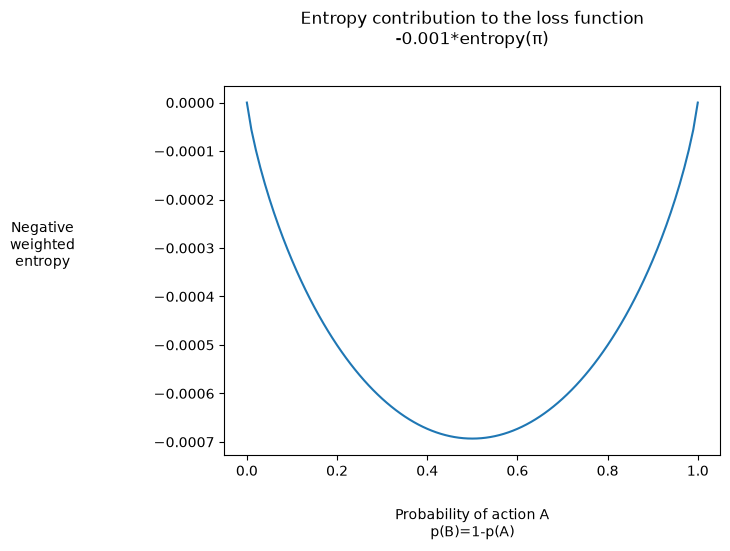

In [28]:
weight, probs, entropies = -0.001, [], []
for p in np.arange(0, 1.01, 0.01):
    probs.append(p)
    p = torch.FloatTensor([p, 1-p])
    d = torch.distributions.Categorical(probs=p)
    entropies.append(weight * d.entropy().item())
plt.plot(probs, entropies)
plt.xlabel('Probability of action A\np(B)=1-p(A)', labelpad=20)
plt.ylabel('Negative\nweighted\nentropy', labelpad=80, rotation=0)
plt.title('Entropy contribution to the loss function\n{}*entropy(π)'.format(weight), pad=30)
plt.show()

In [ ]:
class FCV(nn.Module):
    def __init__(self, 
                 input_dim,
                 hidden_dims=(32,32), 
                 activation_fc=F.relu):
        super(FCV, self).__init__()
        self.activation_fc = activation_fc

        self.input_layer = nn.Linear(input_dim, hidden_dims[0])
        self.hidden_layers = nn.ModuleList()
        for i in range(len(hidden_dims)-1):
            hidden_layer = nn.Linear(hidden_dims[i], hidden_dims[i+1])
            self.hidden_layers.append(hidden_layer)
        self.output_layer = nn.Linear(hidden_dims[-1], 1)

    def _format(self, state):
        x = state
        if not isinstance(x, torch.Tensor):
            x = torch.tensor(x,
                             dtype=torch.float32)
            x = x.unsqueeze(0)
        return x

    def forward(self, state):
        x = self._format(state)
        x = self.activation_fc(self.input_layer(x))
        for hidden_layer in self.hidden_layers:
            x = self.activation_fc(hidden_layer(x))
        return self.output_layer(x)

In [ ]:
class VPG():
    def __init__(self, 
                 policy_model_fn, 
                 policy_model_max_grad_norm, 
                 policy_optimizer_fn, 
                 policy_optimizer_lr,
                 value_model_fn, 
                 value_model_max_grad_norm, 
                 value_optimizer_fn, 
                 value_optimizer_lr, 
                 entropy_loss_weight):
        self.policy_model_fn = policy_model_fn
        self.policy_model_max_grad_norm = policy_model_max_grad_norm
        self.policy_optimizer_fn = policy_optimizer_fn
        self.policy_optimizer_lr = policy_optimizer_lr
        
        self.value_model_fn = value_model_fn
        self.value_model_max_grad_norm = value_model_max_grad_norm
        self.value_optimizer_fn = value_optimizer_fn
        self.value_optimizer_lr = value_optimizer_lr
        
        self.entropy_loss_weight = entropy_loss_weight

    def optimize_model(self):
        T = len(self.rewards)
        discounts = np.logspace(0, T, num=T, base=self.gamma, endpoint=False)
        returns = np.array([np.sum(discounts[:T-t] * self.rewards[t:]) for t in range(T)])
        discounts = torch.FloatTensor(discounts[:-1]).unsqueeze(1)
        returns = torch.FloatTensor(returns[:-1]).unsqueeze(1)

        self.logpas = torch.cat(self.logpas)
        self.entropies = torch.cat(self.entropies) 
        self.values = torch.cat(self.values)

        value_error = returns - self.values
        policy_loss = -(discounts * value_error.detach() * self.logpas).mean()
        entropy_loss = -self.entropies.mean()
        loss = policy_loss + self.entropy_loss_weight * entropy_loss
        self.policy_optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_model.parameters(), 
                                       self.policy_model_max_grad_norm)
        self.policy_optimizer.step()

        value_loss = value_error.pow(2).mul(0.5).mean()
        self.value_optimizer.zero_grad()
        value_loss.backward()
        torch.nn.utils.clip_grad_norm_(self.value_model.parameters(), 
                                       self.value_model_max_grad_norm)
        self.value_optimizer.step()
        
    def interaction_step(self, state, env):
        action, is_exploratory, logpa, entropy = self.policy_model.full_pass(state)
        new_state, reward, is_terminal, info = env.step(action)
        is_truncated = 'TimeLimit.truncated' in info and info['TimeLimit.truncated']

        self.logpas.append(logpa)
        self.entropies.append(entropy)
        self.rewards.append(reward)
        self.values.append(self.value_model(state))

        self.episode_reward[-1] += reward
        self.episode_timestep[-1] += 1
        self.episode_exploration[-1] += int(is_exploratory)
        return new_state, is_terminal, is_truncated

    def train(self, make_env_fn, make_env_kargs, seed, gamma, 
              max_minutes, max_episodes, goal_mean_100_reward):
        training_start, last_debug_time = time.time(), float('-inf')

        self.checkpoint_dir = tempfile.mkdtemp()
        self.make_env_fn = make_env_fn
        self.make_env_kargs = make_env_kargs
        self.seed = seed
        self.gamma = gamma
        
        env = self.make_env_fn(**self.make_env_kargs, seed=self.seed)
        torch.manual_seed(self.seed) ; np.random.seed(self.seed) ; random.seed(self.seed)
    
        nS, nA = env.observation_space.shape[0], env.action_space.n
        self.episode_timestep = []
        self.episode_reward = []
        self.episode_seconds = []
        self.episode_exploration = []
        self.evaluation_scores = []

        self.policy_model = self.policy_model_fn(nS, nA)
        self.policy_optimizer = self.policy_optimizer_fn(self.policy_model, 
                                                         self.policy_optimizer_lr)
        
        self.value_model = self.value_model_fn(nS)
        self.value_optimizer = self.value_optimizer_fn(self.value_model, 
                                                       self.value_optimizer_lr)
        result = np.empty((max_episodes, 5))
        result[:] = np.nan
        training_time = 0
        
        for episode in range(1, max_episodes + 1):
            episode_start = time.time()
            
            state, is_terminal = env.reset(), False
            self.episode_reward.append(0.0)
            self.episode_timestep.append(0.0)
            self.episode_exploration.append(0.0)

            # collect rollout
            self.logpas, self.entropies, self.rewards, self.values = [], [], [], []
            for step in count():
                state, is_terminal, is_truncated = self.interaction_step(state, env)
                if is_terminal:
                    gc.collect()
                    break

            is_failure = is_terminal and not is_truncated
            next_value = 0 if is_failure else self.value_model(state).detach().item()
            self.rewards.append(next_value)
            self.optimize_model()

            # stats
            episode_elapsed = time.time() - episode_start
            self.episode_seconds.append(episode_elapsed)
            training_time += episode_elapsed
            evaluation_score, _ = self.evaluate(self.policy_model, env)
            self.save_checkpoint(episode-1, self.policy_model)

            total_step = int(np.sum(self.episode_timestep))
            self.evaluation_scores.append(evaluation_score)
            
            mean_10_reward = np.mean(self.episode_reward[-10:])
            std_10_reward = np.std(self.episode_reward[-10:])
            mean_100_reward = np.mean(self.episode_reward[-100:])
            std_100_reward = np.std(self.episode_reward[-100:])
            mean_100_eval_score = np.mean(self.evaluation_scores[-100:])
            std_100_eval_score = np.std(self.evaluation_scores[-100:])
            lst_100_exp_rat = np.array(
                self.episode_exploration[-100:])/np.array(self.episode_timestep[-100:])
            mean_100_exp_rat = np.mean(lst_100_exp_rat)
            std_100_exp_rat = np.std(lst_100_exp_rat)

            wallclock_elapsed = time.time() - training_start
            result[episode-1] = total_step, mean_100_reward, \
                mean_100_eval_score, training_time, wallclock_elapsed
            
            reached_debug_time = time.time() - last_debug_time >= LEAVE_PRINT_EVERY_N_SECS
            reached_max_minutes = wallclock_elapsed >= max_minutes * 60
            reached_max_episodes = episode >= max_episodes
            reached_goal_mean_reward = mean_100_eval_score >= goal_mean_100_reward
            training_is_over = reached_max_minutes or \
                               reached_max_episodes or \
                               reached_goal_mean_reward

            elapsed_str = time.strftime("%H:%M:%S", time.gmtime(time.time() - training_start))
            debug_message = 'el {}, ep {:04}, ts {:06}, '
            debug_message += 'ar 10 {:05.1f}\u00B1{:05.1f}, '
            debug_message += '100 {:05.1f}\u00B1{:05.1f}, '
            debug_message += 'ex 100 {:02.1f}\u00B1{:02.1f}, '
            debug_message += 'ev {:05.1f}\u00B1{:05.1f}'
            debug_message = debug_message.format(
                elapsed_str, episode-1, total_step, mean_10_reward, std_10_reward, 
                mean_100_reward, std_100_reward, mean_100_exp_rat, std_100_exp_rat,
                mean_100_eval_score, std_100_eval_score)
            print(debug_message, end='\r', flush=True)
            if reached_debug_time or training_is_over:
                print(ERASE_LINE + debug_message, flush=True)
                last_debug_time = time.time()
            if training_is_over:
                if reached_max_minutes: print(u'--> reached_max_minutes \u2715')
                if reached_max_episodes: print(u'--> reached_max_episodes \u2715')
                if reached_goal_mean_reward: print(u'--> reached_goal_mean_reward \u2713')
                break

        final_eval_score, score_std = self.evaluate(self.policy_model, env, n_episodes=100)
        wallclock_time = time.time() - training_start
        print('Training complete.')
        print('Final evaluation score {:.2f}\u00B1{:.2f} in {:.2f}s training time,'
              ' {:.2f}s wall-clock time.\n'.format(
                  final_eval_score, score_std, training_time, wallclock_time))
        env.close() ; del env
        self.get_cleaned_checkpoints()
        return result, final_eval_score, training_time, wallclock_time

    def evaluate(self, eval_policy_model, eval_env, n_episodes=1, greedy=True):
        rs = []
        for _ in range(n_episodes):
            s, d = eval_env.reset(), False
            rs.append(0)
            for _ in count():
                if greedy:
                    a = eval_policy_model.select_greedy_action(s)
                else: 
                    a = eval_policy_model.select_action(s)
                s, r, d, _ = eval_env.step(a)
                rs[-1] += r
                if d: break
        return np.mean(rs), np.std(rs)

    def get_cleaned_checkpoints(self, n_checkpoints=5):
        try: 
            return self.checkpoint_paths
        except AttributeError:
            self.checkpoint_paths = {}

        paths = glob.glob(os.path.join(self.checkpoint_dir, '*.tar'))
        paths_dic = {int(path.split('.')[-2]):path for path in paths}
        last_ep = max(paths_dic.keys())
        # checkpoint_idxs = np.geomspace(1, last_ep+1, n_checkpoints, endpoint=True, dtype=np.int)-1
        checkpoint_idxs = np.linspace(1, last_ep+1, n_checkpoints, endpoint=True, dtype=np.int)-1

        for idx, path in paths_dic.items():
            if idx in checkpoint_idxs:
                self.checkpoint_paths[idx] = path
            else:
                os.unlink(path)

        return self.checkpoint_paths

    def demo_last(self, title='Fully-trained {} Agent', n_episodes=3, max_n_videos=3):
        env = self.make_env_fn(**self.make_env_kargs, monitor_mode='evaluation', render=True, record=True)

        checkpoint_paths = self.get_cleaned_checkpoints()
        last_ep = max(checkpoint_paths.keys())
        self.policy_model.load_state_dict(torch.load(checkpoint_paths[last_ep]))

        self.evaluate(self.policy_model, env, n_episodes=n_episodes)
        env.close()
        data = get_gif_html(env_videos=env.videos, 
                            title=title.format(self.__class__.__name__),
                            max_n_videos=max_n_videos)
        del env
        return HTML(data=data)

    def demo_progression(self, title='{} Agent progression', max_n_videos=5):
        env = self.make_env_fn(**self.make_env_kargs, monitor_mode='evaluation', render=True, record=True)

        checkpoint_paths = self.get_cleaned_checkpoints()
        for i in sorted(checkpoint_paths.keys()):
            self.policy_model.load_state_dict(torch.load(checkpoint_paths[i]))
            self.evaluate(self.policy_model, env, n_episodes=1)

        env.close()
        data = get_gif_html(env_videos=env.videos, 
                            title=title.format(self.__class__.__name__),
                            subtitle_eps=sorted(checkpoint_paths.keys()),
                            max_n_videos=max_n_videos)
        del env
        return HTML(data=data)

    def save_checkpoint(self, episode_idx, model):
        torch.save(model.state_dict(), 
                   os.path.join(self.checkpoint_dir, 'model.{}.tar'.format(episode_idx)))

In [ ]:

SEEDS = [1]
vpg_results = []
best_agent, best_eval_score = None, float('-inf')
for seed in SEEDS:
    environment_settings = {
        'env_name': 'CartPole-v1',
        'gamma': 1.00,
        'max_minutes': 10,
        'max_episodes': 10000,
        'goal_mean_100_reward': 475
    }

    policy_model_fn = lambda nS, nA: FCDAP(nS, nA, hidden_dims=(128,64))
    policy_model_max_grad_norm = 1
    policy_optimizer_fn = lambda net, lr: optim.Adam(net.parameters(), lr=lr)
    policy_optimizer_lr = 0.0005

    value_model_fn = lambda nS: FCV(nS, hidden_dims=(256,128))
    value_model_max_grad_norm = float('inf')
    value_optimizer_fn = lambda net, lr: optim.RMSprop(net.parameters(), lr=lr)
    value_optimizer_lr = 0.0007

    entropy_loss_weight = 0.001

    env_name, gamma, max_minutes, \
    max_episodes, goal_mean_100_reward = environment_settings.values()
    agent = VPG(policy_model_fn, 
                policy_model_max_grad_norm, 
                policy_optimizer_fn, 
                policy_optimizer_lr,
                value_model_fn, 
                value_model_max_grad_norm, 
                value_optimizer_fn, 
                value_optimizer_lr, 
                entropy_loss_weight)

    make_env_fn, make_env_kargs = get_make_env_fn(env_name=env_name)
    result, final_eval_score, training_time, wallclock_time = agent.train(
        make_env_fn, make_env_kargs, seed, gamma, max_minutes, max_episodes, goal_mean_100_reward)
    vpg_results.append(result)
    if final_eval_score > best_eval_score:
        best_eval_score = final_eval_score
        best_agent = agent
vpg_results = np.array(vpg_results)
_ = BEEP()